# Lab: Cross-Validation


**Instructions**

* Read and complete all exercises below in the provided `.qmd` notebook (or `.ipynb` file if you prefer, both files are identical aside from the formatting)
  
**Submission:**

* You need to upload ONE document to Canvas when you are done. 
* A PDF (or HTML) of the completed form of this notebook
* The final uploaded version should NOT have any code-errors present. 
* All outputs must be visible in the uploaded version, including code-cell outputs, images, graphs, etc

**Optional**: 

* You can actually work in `R` now inside VS-code using the `.ipynb` format
* Its quite easy to get working: [click here for instructions](https://www.practicaldatascience.org/html/jupyter_r_notebooks.html)
* There are a few benefits to this 
  * (1) You can work 100% in VS-Code (for both R and Python), no need to switch between VSC and R-studio
  * (2) You can work through your cells one at a time and see the incremental progress, similar to using `.ipynb` with python or `rmd` in R-studio.
* With Quarto's `convert` command, you can re-format and jump between the different file-formats. For example, 
* `quarto convert HW-2.rmd` will convert the file to `HW-2.ipynb`
* `quarto convert HW-2.ipynb` will convert the file to `HW-2.qmd`, which can be renamed `HW-2.rmd` or just opened in R-studio like any other `rmd` file, just like normal.
* `quarto render HW-2.ipynb` will render the notebook (either R or Python) into an aesthetically pleasing output.

## Part-1: Demonstration
We will work through the following section in class as a technical example.

### Import

In [32]:
# install.packages("ISLR");
library(ISLR) 
require(boot)

In [33]:
# GET INFO ABOUT CROSS VALIDATION PACKAGE
?cv.glm

cv.glm                  package:boot                   R Documentation

_C_r_o_s_s-_v_a_l_i_d_a_t_i_o_n _f_o_r _G_e_n_e_r_a_l_i_z_e_d _L_i_n_e_a_r _M_o_d_e_l_s

_D_e_s_c_r_i_p_t_i_o_n:

     This function calculates the estimated K-fold cross-validation
     prediction error for generalized linear models.

_U_s_a_g_e:

     cv.glm(data, glmfit, cost, K)
     
_A_r_g_u_m_e_n_t_s:

    data: A matrix or data frame containing the data.  The rows should
          be cases and the columns correspond to variables, one of
          which is the response.

  glmfit: An object of class '"glm"' containing the results of a
          generalized linear model fitted to 'data'.

    cost: A function of two vector arguments specifying the cost
          function for the cross-validation.  The first argument to
          'cost' should correspond to the observed responses and the
          second argument should correspond to the predict

In [34]:
# GET DATA
data(Auto)
df=Auto

# EXPLORE DATA
print(class(df))
print(dim(df))
print(df[1:3,1:8])

[1] "data.frame"
[1] 392   9
  mpg cylinders displacement horsepower weight acceleration year origin
1  18         8          307        130   3504         12.0   70      1
2  15         8          350        165   3693         11.5   70      1
3  18         8          318        150   3436         11.0   70      1


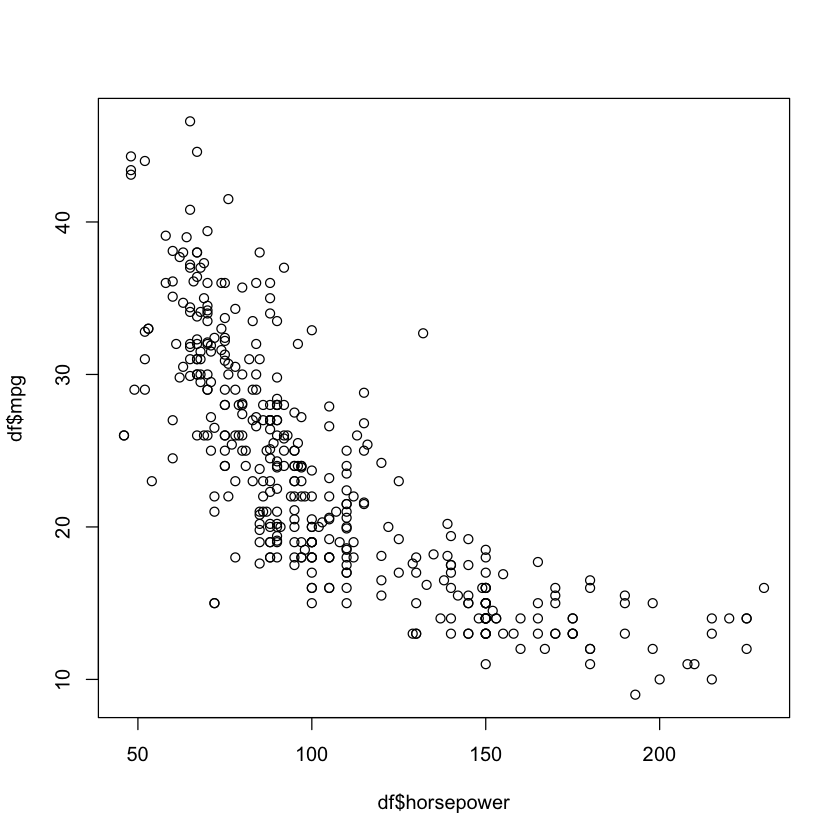

In [35]:
# PLOT THE DATA 
# plot(mpg~horsepower,data = Auto)
plot(df$horsepower,df$mpg)

### Leave-One-Out Cross-Validation

We can do a linear fit as usual with `lm` function

In [36]:
lm.fit=lm(mpg~horsepower,data=df)
# print(lm.fit)
print(coef(lm.fit))

(Intercept)  horsepower 
 39.9358610  -0.1578447 


If we use glm() to fit a model without passing in the family argument, then it performs linear regression, just like the lm() function.

(Intercept)  horsepower 
 39.9358610  -0.1578447 
(Intercept)  horsepower 
 39.9358610  -0.1578447 


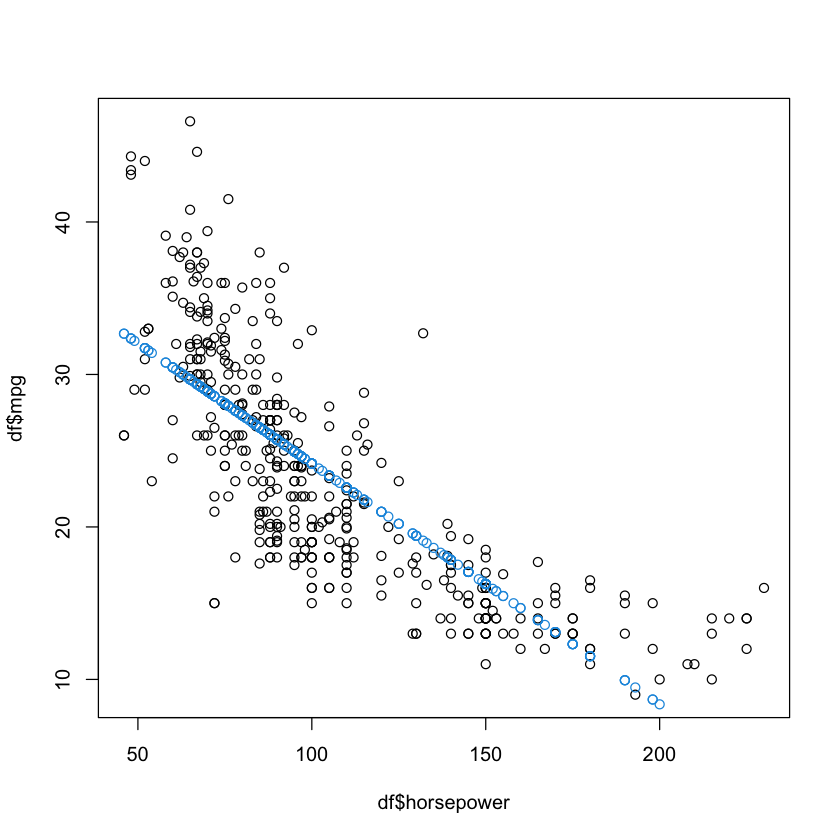

In [37]:
# FIT THE MODEL 
# glm.fit=glm(mpg~horsepower,data=Auto)
glm.fit=glm(mpg~horsepower,data=df)
print(coef(glm.fit))

# PLOT THE RESULTS
b=coef(glm.fit)[1]
m=coef(glm.fit)[2]
print(c(b,m))
plot(df$horsepower,df$mpg)
points(df$horsepower,m*df$horsepower+b, col = "#1b98e0")

You can see the result in identical linear regression models.

We will perform linear regression using the glm() function rather than the lm() function because the former can be used together with the cv.glm() function, which is part of the boot library.

In [38]:
cv=cv.glm(Auto,glm.fit) #pretty slow (doesn't use  formula (5.2))

In [39]:
print(summary(cv))
print(cv$delta)

      Length Class  Mode   
call    3    -none- call   
K       1    -none- numeric
delta   2    -none- numeric
seed  626    -none- numeric
[1] 24.23151 24.23114


In [40]:
## PRINT MSE, RMSE 
ypred=m*df$horsepower+b
y=df$mpg
res=(y-ypred)
print(mean(res**2))
print(mean(abs(res)))
print(mean(res**2)**0.5)

[1] 23.94366
[1] 3.827587
[1] 4.893226


The cv.glm() function produces a list with several components. The two numbers in the delta vector contain the cross-validation results.

The first number we see above is raw the LOOCV result, and the second number is a bias corrected version of it. 

The Bias correction is because the data set that we train on is slightly smaller than the one that we actually would like to get the error for, which is the full data set of size n.

It has more of an effect for K-fold CV. (The adjustment is designed to compensate for the bias introduced by not using leave-one-out cross-validation.)

On this data set, the two estimates are very similar to each other.

This command will likely take a couple of minutes to run.

Let's write a simple function to use formula(5.2)


$$\mathrm{CV}_{(n)}=\frac{1}{n} \sum_{i=1}^n\left(\frac{y_i-\hat{y}_i}{1-h_i}\right)^2 \,\,\,\,\,\,\,\,\,\,(5.2)$$

In [41]:
loocv=function(fit){ #function loocv takes the fit as the argument
  h =lm.influence(fit)$h #lm.influence is a post-processor for lm.fit
  #will extract the element h from that which gives you the diagonal elements
  #of the hat matrix =levarage => put that in a vector h
  mean((residuals(fit)/(1-h))^2) #formula 5.2
  }

#Now lets try it

loocv(glm.fit)

[1] 24.23151

This runs very quickly, and has the same as the result from the previous glm.fit, showing our function works.

Now let's fit polynomials of different degrees(1-5). Because the data looks very non linear.

[1] 24.23151 19.24821 19.33498 19.42443 19.03321


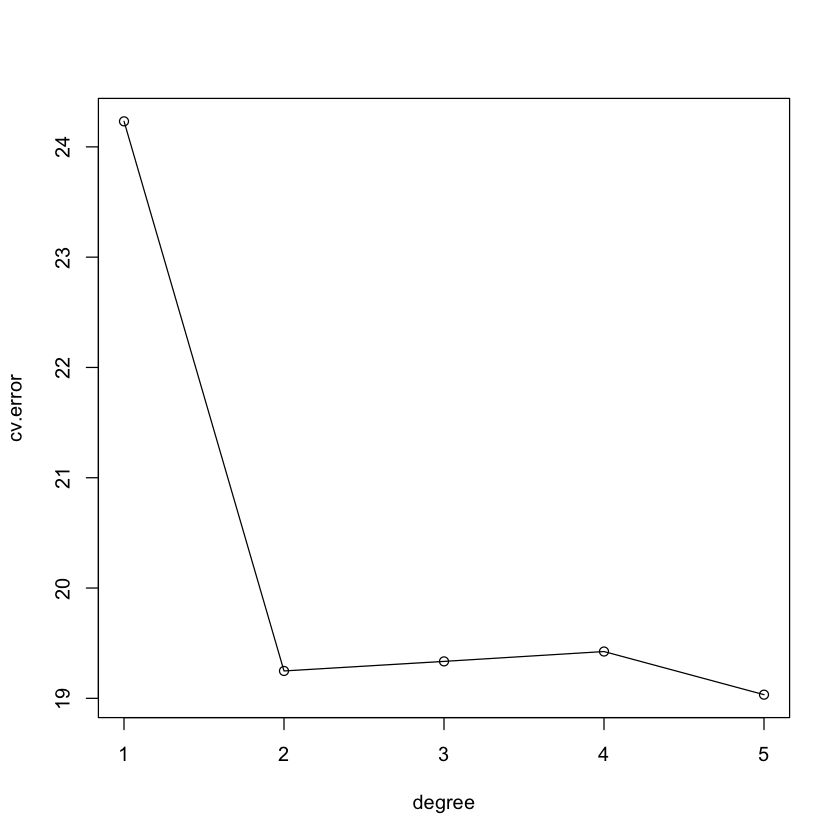

In [42]:
# This code computes the leave-one-out cross-validation errors for polynomial regression models with degrees ranging from 1 to 5 and then plots these errors against the degrees of polynomial. It iterates through each degree, fits a polynomial regression model, computes the leave-one-out cross-validation error using the loocv function, and stores the errors in the vector cv.error. Finally, it prints the errors and creates a plot to visualize how the errors vary with the degrees of polynomial.


# Initialize a vector to store cross-validation errors for degrees 1 to 5
cv.error = rep(0, 5)

# Define degrees of polynomial from 1 to 5
degree = 1:5

# Loop through degrees of polynomial
for (d in degree) {
  # Fit a generalized linear model (GLM) using polynomial regression of degree 'd'
  glm.fit = glm(mpg ~ poly(horsepower, d), data = Auto)
  # Compute the leave-one-out cross-validation error and store it
  cv.error[d] = loocv(glm.fit)  # a vector to collect errors
}

# Print the cross-validation errors
print(cv.error)

# Plot the cross-validation errors against the degrees of polynomial
plot(degree, cv.error, type = 'o')  # plot the error against the degree







Degree 1 does poorly. Degree 2 error jumps down from 24 down to just above 19. Higher degrees really don't make much difference.

By looking at the graph we can conclude that a quadratic model will be a good fit.

### (K=5)-Fold Cross-Validation

[1] 24.27207 19.26909 19.34805 19.29496 19.03198


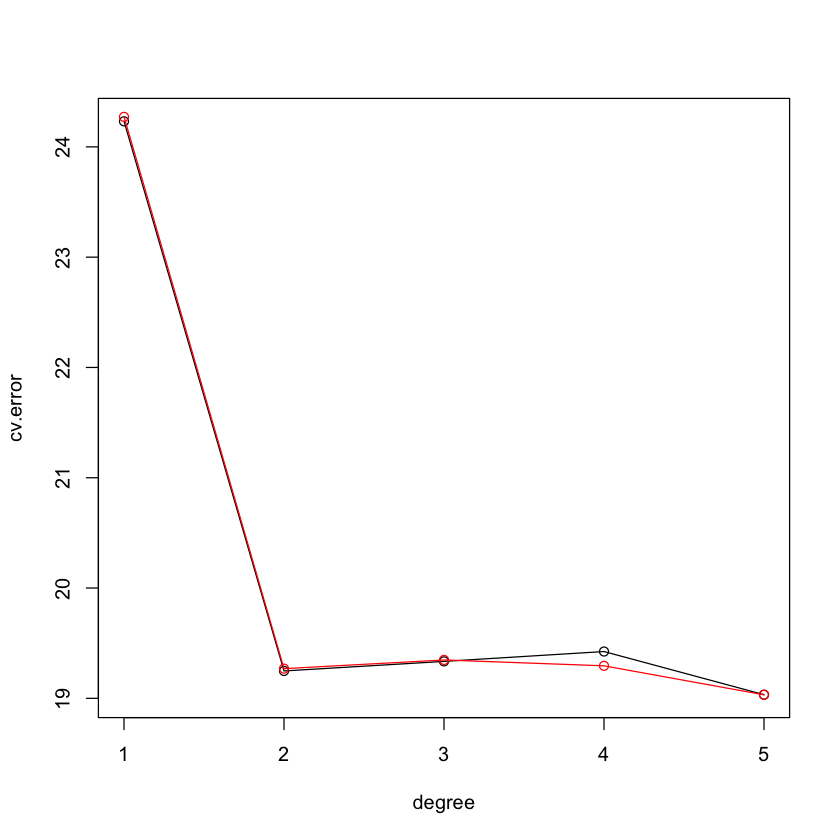

In [43]:
# Set seed for reproducibility
set.seed(17)

# Initialize a vector to store cross-validation errors for degree 1 to 5
cv.error.5 = rep(0, 5)

# Loop through degrees of polynomial (1 to 5)
for (d in degree) {
  # Fit a generalized linear model (GLM) using polynomial regression
  glm.fit = glm(mpg ~ poly(horsepower, d), data = Auto)
  # Store the cross-validation error for each degree of polynomial
  cv.error.5[d] = cv.glm(Auto, glm.fit, K = 10)$delta[1]  # K=10 is the number of folds.
}

# Print the cross-validation errors for degree 1 to 5
print(cv.error.5)

# Plot the cross-validation errors against degrees of polynomial for degree 1 to 10
plot(degree, cv.error, type = 'o')
# Add the cross-validation errors for degree 1 to 5 to the plot in red
lines(degree, cv.error.5, type = "o", col = "red")


It's not much different but more stable (less variation) than LOOCV.

Notice that the computation time is much shorter than that of LOOCV.

### Auto example

(a). What is the best model? 

Best  model: $mpg = -120.14* horsepower + 44.09*(horsepower)^2$  


(b) Compare the cross validation error rate for different splits.


Call:
glm(formula = mpg ~ poly(horsepower, 2), data = Auto)

Deviance Residuals: 
     Min        1Q    Median        3Q       Max  
-14.7135   -2.5943   -0.0859    2.2868   15.8961  

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)            23.4459     0.2209  106.13   <2e-16 ***
poly(horsepower, 2)1 -120.1377     4.3739  -27.47   <2e-16 ***
poly(horsepower, 2)2   44.0895     4.3739   10.08   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for gaussian family taken to be 19.13118)

    Null deviance: 23819  on 391  degrees of freedom
Residual deviance:  7442  on 389  degrees of freedom
AIC: 2274.4

Number of Fisher Scoring iterations: 2


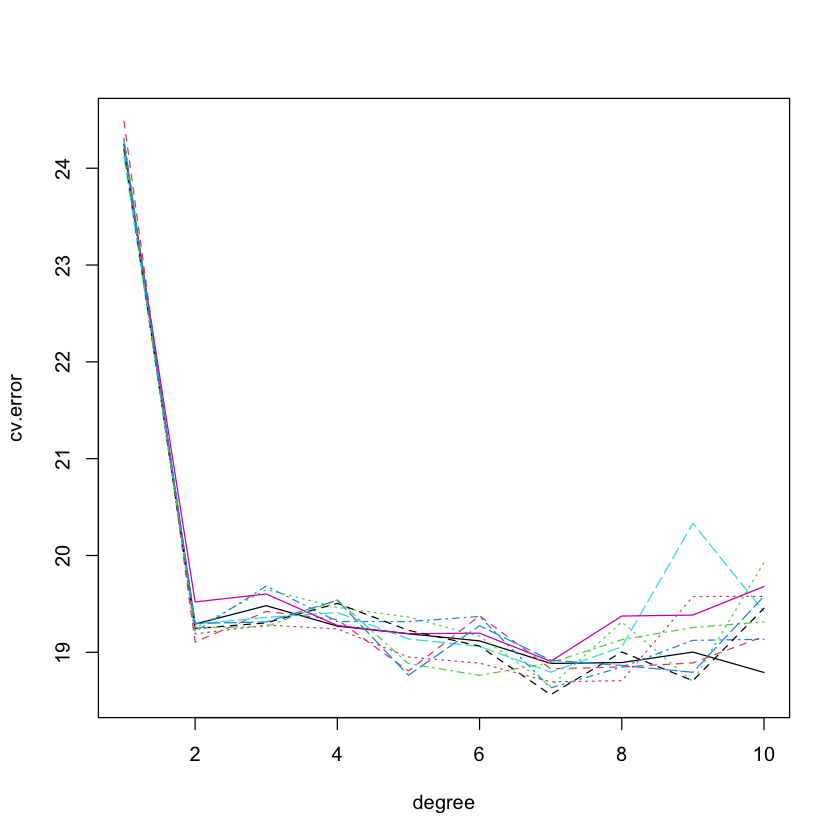

In [44]:
# Initialize a matrix to store cross-validation errors
cv.error = matrix(data = NA, nrow = 10, ncol = 10)

# Loop through degrees of polynomial (1 to 10)
for (j in 1:10) {
  # Loop through iterations for 10-fold cross-validation
  for (i in 1:10) {
    # Fit a generalized linear model (GLM) using polynomial regression
    glm.fit = glm(mpg ~ poly(horsepower, i), data = Auto)
    # Store the cross-validation error in the matrix
    cv.error[i, j] = cv.glm(Auto, glm.fit, K = 10)$delta[1]
  }
}

# Define degrees of polynomial
degree = 1:10

# Plot the cross-validation errors against degrees of polynomial
matplot(degree, cv.error, type = "l")

# Fit the best model with degree 2 polynomial
glm.fit = glm(mpg ~ poly(horsepower, 2), data = Auto)

# Display summary of the best model
summary(glm.fit)


### Example

Consider the built-in data set __cars__ . We wish to predict the braking distance __dist__ from __speed__. Use leave-one-out cross validation to find the best polynomial regression model. Repeat with 10-fold cross validation. Compare the two answers. 

__Solution.__

First, use leave-one-out cross validation. We can use degrees 1 to 15 to fit polynomial models.

Next Plot the results. It turns out that the delta values of very large if the degree of the polynomial is large., therefore it is better to plot the logarithms (done below).

The model with minimal delta for leave-one-out cross validation is 2 (black circle).

The model with minimal delta for 10-fold  cross validation is also 2 (red triangle). _This depends on the random seed with which the cross validation is done._ 

In [45]:
# GET DATA

# Set seed for reproducibility
set.seed(101)

# Load the datasets library
library(datasets)

# Load the 'cars' dataset
data(cars)

# Create a data frame to store results with degrees ranging from 1 to 15
results.41 <- data.frame(degree = 1:15, delta.loo = NA, delta.k10 = NA)


In [46]:
# DATAFRAME FOR OUTPUTS
print(head(cars))
print(dim(cars))

  speed dist
1     4    2
2     4   10
3     7    4
4     7   22
5     8   16
6     9   10
[1] 50  2


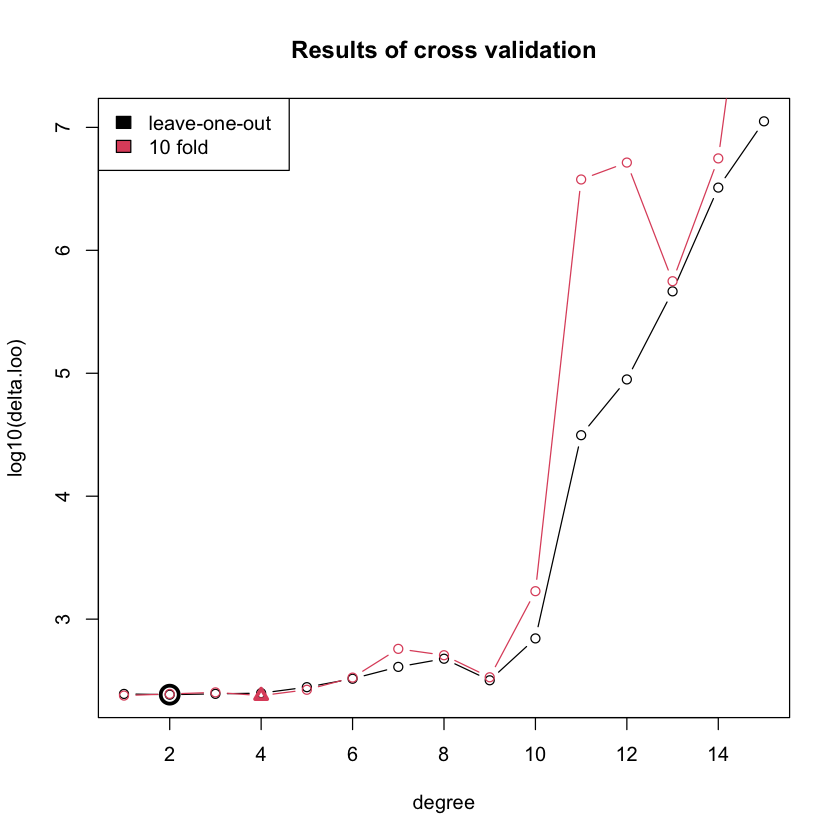

In [47]:
# Commenting the code

# Loop through degrees of polynomial from 1 to 15
for (j in 1:15) {
  # Fit a generalized linear model (GLM) using polynomial regression
  fit.41 = glm(dist ~ poly(speed, j), data = cars)
  
  # Perform leave-one-out cross-validation
  fit.loo <- cv.glm(cars, fit.41, K = 50)  # Using 50-fold cross-validation
  
  # Perform 10-fold cross-validation
  fit.k10 <- cv.glm(cars, fit.41, K = 10)   # Using 10-fold cross-validation
  
  # Store the delta values for each degree of polynomial
  results.41$delta.loo[j] <- fit.loo$delta[1]  # Store leave-one-out delta
  results.41$delta.k10[j] <- fit.k10$delta[1]  # Store 10-fold delta
}

# Plotting the results of cross-validation
plot(log10(delta.loo) ~ degree, data = results.41, type = 'b',
     main = "Results of cross validation")

# Adding legend to the plot
legend(x = "topleft", legend = c("leave-one-out", "10 fold"), fill = 1:2)

# Finding the degree of polynomial with the minimum delta for leave-one-out cross-validation
n.1 <- which.min(results.41$delta.loo)
points(n.1, log10(results.41$delta.loo[n.1]), lwd = 3, col = 1, cex = 2)

# Finding the degree of polynomial with the minimum delta for 10-fold cross-validation
n.2 <- which.min(results.41$delta.k10)
points(n.2, log10(results.41$delta.k10[n.2]), lwd = 3, pch = 2, col = 2)

# Adding lines to the plot for 10-fold cross-validation
lines(log10(delta.k10) ~ degree, data = results.41, type = 'b', col = 2)


## Part-2: Lab Assignment

### Cross Validation Approaches

We'll consider a regression problem with the Carseats dataset.

**Question-2.1.1** Fit a linear model to predict Sales from all other attributes. Looking at the model summary, what is the residual error?

In [48]:
# INSERT CODE HERE

**Lab-2.1.2** Fit another linear model, but now do not include the predictors Population, Education, Urban, and US. What is the residual error? 

In [49]:
# INSERT CODE HERE

**Lab-2.1.3**  How do determine which model is better? Create a train/test split of the data and retrain your model. 

Use the fitted model to make predictions on the test set, and check the model performance by calculating the root mean squared error and R squared values. 

Conduct this for both the model from part (1) and part (2)).

Discuss in text which model is the best and why?

In [50]:
# INSERT CODE HERE

for part (1)

In [51]:
# INSERT CODE HERE

In [52]:
# INSERT CODE HERE

In [53]:
# INSERT CODE HERE

for part (2)

In [54]:
# INSERT CODE HERE

In [55]:
# INSERT CODE HERE

In [56]:
# INSERT CODE HERE

**Lab-2.1.4**  Use the cv.glm() function from the 'boot' library to conduct a cross validation analysis. Run 5-fold, 10-fold, and Leave One Out cross validation for part 1 and 2. Which model has a lower error?

In [57]:
# INSERT CODE HERE

In [58]:
# INSERT CODE HERE

### CV for Model Selection

Here is a synthetic (noisy) dataset.

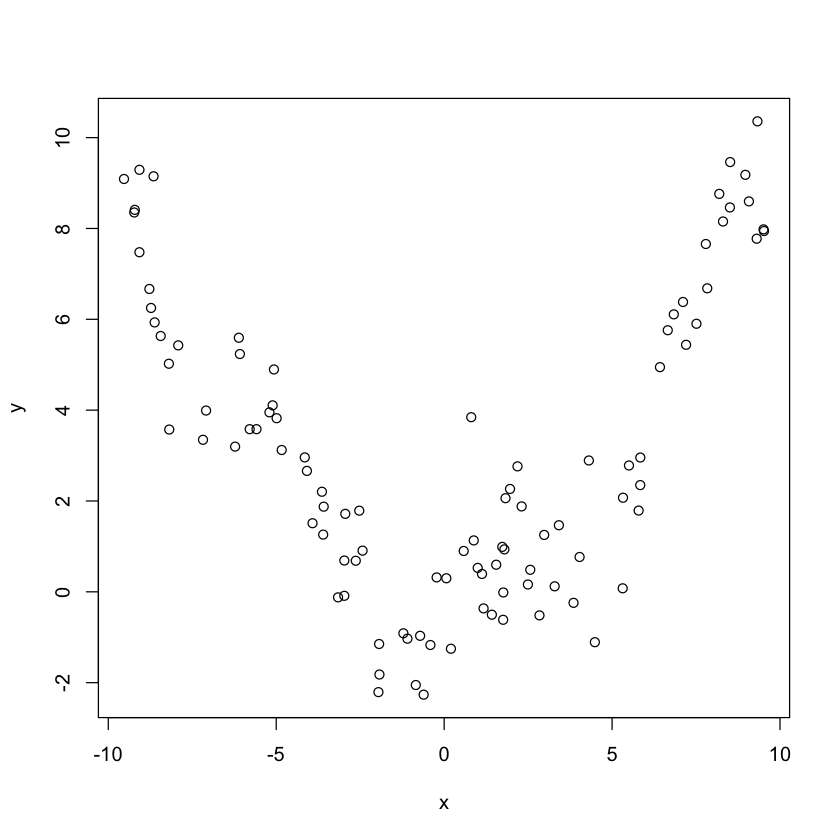

In [59]:
mydf = data.frame(x = runif(100,min = -10, max = 10))
mydf$y = sin(mydf$x) + .1*mydf$x^2 + rnorm(100)
plot(y ~ x, data = mydf)

**Lab-2.1.5**  Fit a linear model to this data. Use 10-fold CV to estimate the error. 

In [60]:
# INSERT CODE HERE

**Lab-2.1.6**  Use the poly() function to fit a quadratic model to this data. Use 10-fold CV to estimate the error.

In [61]:
# INSERT CODE HERE

**Lab-2.1.7**  Repeat this for polynomials up to order 15. Make a plot of the generalization error (calculated from CV) versus the order of the polynomial. 

In [62]:
# INSERT CODE HERE